In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/CS464/

/content/drive/MyDrive/CS464


In [3]:
# !mkdir -p FMA
# %cd FMA

In [4]:
# !git clone https://github.com/mdeff/fma.git

In [5]:
# !cd fma

# !curl -O https://os.unil.cloud.switch.ch/fma/fma_metadata.zip
# !curl -O https://os.unil.cloud.switch.ch/fma/fma_small.zip

# !echo "f0df49ffe5f2a6008d7dc83c6915b31835dfe733  fma_metadata.zip" | sha1sum -c -
# !echo "ade154f733639d52e35e32f5593efe5be76c6d70  fma_small.zip"    | sha1sum -c -

# !unzip fma_metadata.zip
# !unzip fma_small.zip

# !cd ..

In [6]:
!pip install torch torchvision torchaudio librosa matplotlib seaborn tqdm

import os
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 127.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 104.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvji

In [7]:
tracks = pd.read_csv("/content/drive/MyDrive/CS464/FMA/fma_metadata/tracks.csv", index_col=0, header=[0, 1])
genre_top = tracks[('track', 'genre_top')].dropna()

file_paths = []
labels = []

for track_id, genre in genre_top.items():
    folder = str(track_id).zfill(6)[:3]
    path = f"/content/drive/MyDrive/CS464/FMA/fma_small/{folder}/{str(track_id).zfill(6)}.mp3"
    if os.path.exists(path):
        file_paths.append(path)
        labels.append(genre)

metadata = pd.DataFrame({'filename': file_paths, 'genre': labels})
label_map = {g: i for i, g in enumerate(sorted(set(labels)))}
metadata['label'] = metadata['genre'].map(label_map)


In [8]:
import librosa
import numpy as np
from tqdm import tqdm

# Constants
SAMPLE_RATE = 22050
DURATION = 10
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512
IMG_SIZE = 224

def load_audio_clip(path, center_crop=False):
    y, sr = librosa.load(path, sr=SAMPLE_RATE)
    if len(y) < SAMPLES_PER_TRACK:
        y = np.pad(y, (0, SAMPLES_PER_TRACK - len(y)))
    else:
        start = (len(y) - SAMPLES_PER_TRACK) // 2 if center_crop else np.random.randint(0, len(y) - SAMPLES_PER_TRACK)
        y = y[start:start + SAMPLES_PER_TRACK]
    return y

def audio_to_log_mel_spectrogram(y):
    mel = librosa.feature.melspectrogram(y=y, sr=SAMPLE_RATE, n_fft=N_FFT,
                                         hop_length=HOP_LENGTH, n_mels=N_MELS)
    log_mel = librosa.power_to_db(mel, ref=np.max)

    eps = 1e-6  # avoid division by zero
    log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + eps)
    return log_mel



In [17]:
X_data = []
y_data = []

for i, row in tqdm(metadata.iterrows(), total=len(metadata)):
    path = row['filename']
    label = row['label']
    try:
        y = load_audio_clip(path)
        spec = audio_to_log_mel_spectrogram(y)

        # Skip bad spectrograms
        if np.isnan(spec).any() or np.isinf(spec).any():
            continue

        spec_resized = np.resize(spec, (IMG_SIZE, IMG_SIZE))
        rgb_spec = np.stack([spec_resized]*3, axis=-1)

        X_data.append(rgb_spec)
        y_data.append(label)
    except Exception as e:
        print(f"Skipping {path} due to error: {e}")

X = np.array(X_data).astype(np.float32)
y = np.array(y_data)

np.save("spectrogram_images.npy", X)
np.save("labels.npy", y)



 55%|█████▌    | 4423/8000 [09:34<07:10,  8.31it/s]<ipython-input-8-d985cfe5e206>:15: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=SAMPLE_RATE)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 55%|█████▌    | 4424/8000 [09:35<07:56,  7.50it/s]<ipython-input-8-d985cfe5e206>:15: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=SAMPLE_RATE)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 55%|█████▌    | 4425/8000 [09:35<08:31,  6.99it/s]<ipython-input-8-d985cfe5e206>:

Skipping /content/drive/MyDrive/CS464/FMA/fma_small/099/099134.mp3 due to error: 


 59%|█████▉    | 4721/8000 [10:14<06:35,  8.30it/s]<ipython-input-8-d985cfe5e206>:27: RuntimeWarning: invalid value encountered in divide
  log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min())
 61%|██████▏   | 4903/8000 [10:38<08:29,  6.08it/s]<ipython-input-8-d985cfe5e206>:15: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=SAMPLE_RATE)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 61%|██████▏   | 4905/8000 [10:38<08:11,  6.29it/s]

Skipping /content/drive/MyDrive/CS464/FMA/fma_small/108/108925.mp3 due to error: 


 63%|██████▎   | 5050/8000 [10:56<06:16,  7.83it/s]<ipython-input-8-d985cfe5e206>:27: RuntimeWarning: invalid value encountered in divide
  log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min())
 87%|████████▋ | 6965/8000 [15:09<02:14,  7.70it/s]<ipython-input-8-d985cfe5e206>:15: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=SAMPLE_RATE)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 87%|████████▋ | 6966/8000 [15:09<02:15,  7.64it/s]

Skipping /content/drive/MyDrive/CS464/FMA/fma_small/133/133297.mp3 due to error: 


100%|██████████| 8000/8000 [17:26<00:00,  7.64it/s]


In [29]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split

class SpectrogramDataset(Dataset):
    def __init__(self, data, labels, transform=None):
        self.data = data
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = self.data[idx]  # NumPy array (H, W, C)
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# Load .npy files
X = np.load("spectrogram_images.npy")
y = np.load("labels.npy")

from sklearn.utils import shuffle

X, y = shuffle(X, y, random_state=42)  # shuffles data and labels in sync

# Train-val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
from sklearn.utils.class_weight import compute_class_weight
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Compute weights
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
weights = torch.tensor(weights, dtype=torch.float).to(device)


import torchvision.transforms as transforms

# Eğitim veri artırımı (augmentasyon) + normalize
transform_train = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# Doğrulama için sadece normalize
transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

train_dataset = SpectrogramDataset(X_train, y_train, transform=transform_train)
val_dataset = SpectrogramDataset(X_val, y_val, transform=transform_val)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)


In [33]:
import torch.nn as nn

class CNNGenreClassifier(nn.Module):
    def __init__(self):
        super(CNNGenreClassifier, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(0.25),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(0.25),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(0.25),
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, len(np.unique(y)))  # dynamic number of genres
        )

    def forward(self, x):
        x = self.conv_layers(x)
        return self.fc_layers(x)


In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = CNNGenreClassifier().to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy

# Learning rate scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5, verbose=True)

# Early stopping setup
best_val_acc = 0
patience = 10
patience_counter = 0
best_model_weights = copy.deepcopy(model.state_dict())


train_acc, val_acc = [], []

for epoch in range(40):
    model.train()
    correct, total = 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    train_acc.append(correct / total)

    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc.append(correct / total)

    print(f"Epoch {epoch+1}: Train Acc = {train_acc[-1]:.4f}, Val Acc = {val_acc[-1]:.4f}")

    # ✅ BU BLOK for döngüsünün içine girmeli
    scheduler.step(val_acc[-1])

    if val_acc[-1] > best_val_acc:
        best_val_acc = val_acc[-1]
        best_model_weights = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# En iyi modeli geri yükle
model.load_state_dict(best_model_weights)
torch.save(model.state_dict(), "cnn_genre_classifier_best.pt")
print("Model successfully saved as cnn_genre_classifier_best.pt")



Using device: cuda


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1: Train Acc = 0.1907, Val Acc = 0.2245
Epoch 2: Train Acc = 0.2605, Val Acc = 0.2821
Epoch 3: Train Acc = 0.2789, Val Acc = 0.3333
Epoch 4: Train Acc = 0.3053, Val Acc = 0.3396
Epoch 5: Train Acc = 0.3243, Val Acc = 0.3646
Epoch 6: Train Acc = 0.3330, Val Acc = 0.3684
Epoch 7: Train Acc = 0.3491, Val Acc = 0.3408
Epoch 8: Train Acc = 0.3454, Val Acc = 0.3734
Epoch 9: Train Acc = 0.3601, Val Acc = 0.3734
Epoch 10: Train Acc = 0.3666, Val Acc = 0.3784
Epoch 11: Train Acc = 0.3654, Val Acc = 0.3790
Epoch 12: Train Acc = 0.3873, Val Acc = 0.3877
Epoch 13: Train Acc = 0.3801, Val Acc = 0.3734
Epoch 14: Train Acc = 0.3912, Val Acc = 0.4090
Epoch 15: Train Acc = 0.3965, Val Acc = 0.3984
Epoch 16: Train Acc = 0.4013, Val Acc = 0.3921
Epoch 17: Train Acc = 0.4093, Val Acc = 0.4146
Epoch 18: Train Acc = 0.4110, Val Acc = 0.4153
Epoch 19: Train Acc = 0.4154, Val Acc = 0.4084
Epoch 20: Train Acc = 0.4153, Val Acc = 0.4165
Epoch 21: Train Acc = 0.4145, Val Acc = 0.4184
Epoch 22: Train Acc = 

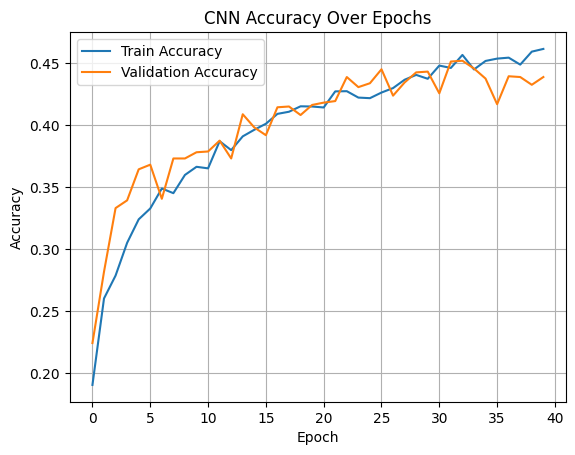

               precision    recall  f1-score   support

   Electronic       0.45      0.39      0.42       200
 Experimental       0.47      0.18      0.26       199
         Folk       0.37      0.73      0.49       200
      Hip-Hop       0.60      0.51      0.55       200
 Instrumental       0.47      0.53      0.50       200
International       0.46      0.47      0.47       200
          Pop       0.29      0.15      0.20       200
         Rock       0.52      0.66      0.58       200

     accuracy                           0.45      1599
    macro avg       0.45      0.45      0.43      1599
 weighted avg       0.45      0.45      0.43      1599



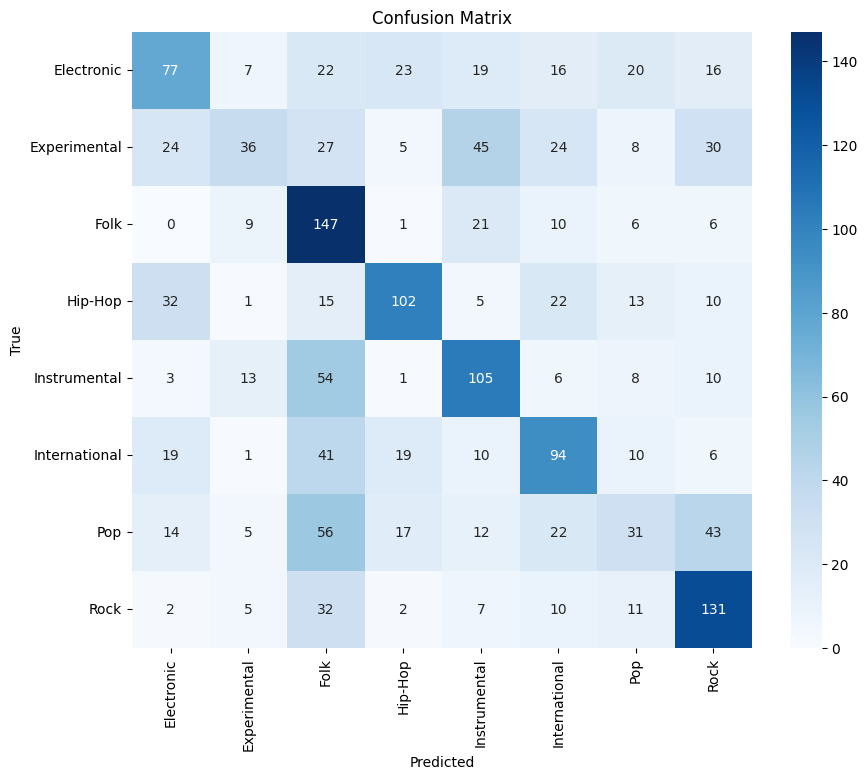

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Plot accuracy
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy Over Epochs")
plt.legend()
plt.grid()
plt.show()

# Evaluation
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

genre_names = list(np.unique(metadata['genre']))

print(classification_report(y_true, y_pred, target_names=genre_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=genre_names, yticklabels=genre_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
